# Assignment 04: Predicting Stroke Risks – Healthcare Data Pipeline

---

## Assignment Overview

**Domain:** Healthcare / Medical Diagnosis

**Objective:** Prepare a clean, processed, and analysis-ready dataset for stroke prediction. Your goal is to handle messy data, perform exploratory analysis, and apply preprocessing techniques to make the data ready for machine learning.

**Dataset:** Stroke Prediction Dataset from Kaggle

**Target Variable/Column:** `stroke` (0 = No Stroke, 1 = Stroke)

---

## Part 1: Data Loading & Initial Inspection

### Task 1.1: Import Required Libraries

Import the following libraries:
- `pandas` as `pd`
- `numpy` as `np`
- `matplotlib.pyplot` as `plt`
- `seaborn` as `sns`

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1.2: Load the Dataset

Load the `healthcare-dataset-stroke-data.csv` file into a pandas DataFrame named `df`.

**Note:** Make sure the dataset file is in the same directory as this notebook, or provide the correct path.

In [154]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

### Task 1.3: Display First 5 Rows

Display the first 5 rows of the dataset to get a quick overview.

In [81]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Task 1.4: Dataset Information

Use `.info()` to identify:
- Data types of each column
- Number of non-null values
- Memory usage

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


### Task 1.5: Statistical Summary

Use `.describe()` to check statistical summaries of numerical columns.

In [83]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


---

## Part 2: Exploratory Data Analysis (EDA) & Visualization

### Task 2.1: Target Variable Analysis

Create a countplot for the `stroke` column to visualize the class distribution.

<Axes: xlabel='stroke', ylabel='count'>

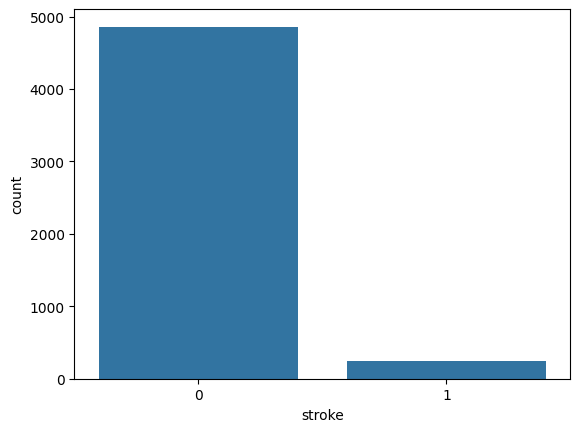

In [84]:
# Countplot for stroke variable
sns.countplot(data=df , x="stroke")

### Task 2.2: Categorical Features Visualization

Create countplots for the following categorical features, split by the target variable (use `hue='stroke'`):
1. `gender`
2. `work_type`
3. `smoking_status`

**Important:**
Plot them side by side. Use subplots to organize your visualizations.

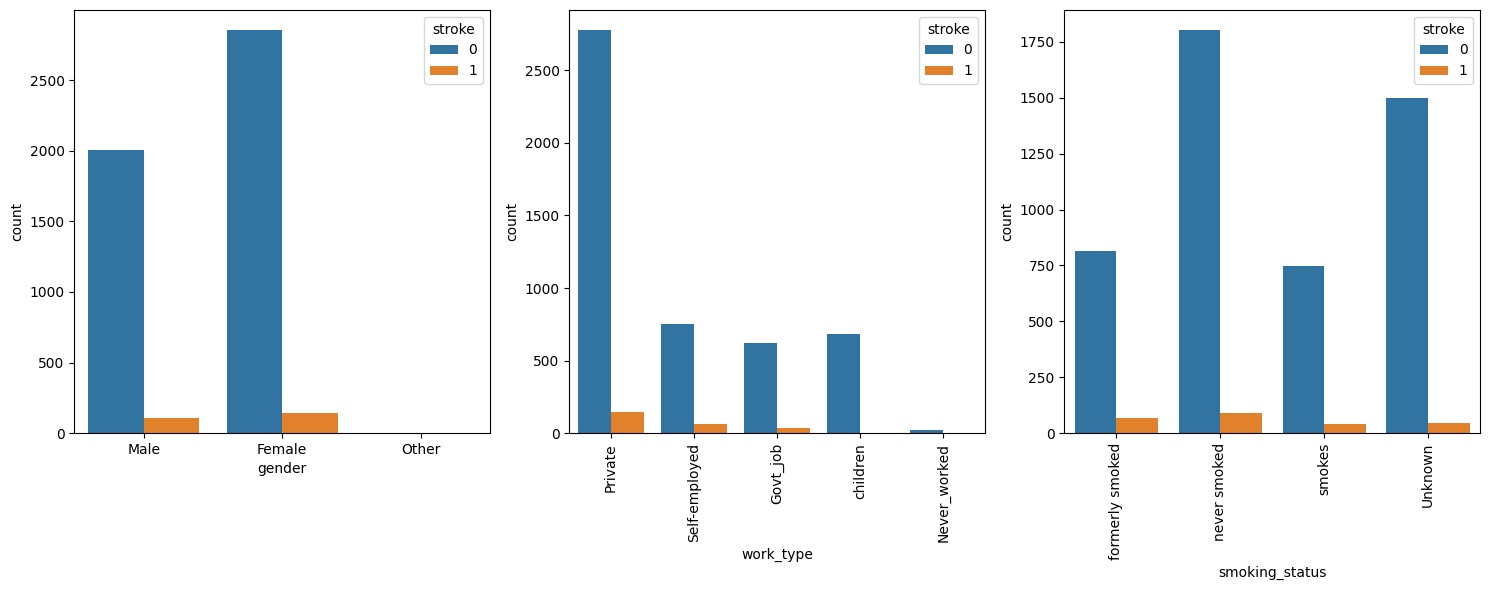

In [85]:
# Countplot for gender, work_type and smoking_status
plt.figure(figsize=(15,6))

plt.subplot(1,3,1)
sns.countplot(data=df,x="gender",hue="stroke")

plt.subplot(1,3,2)
sns.countplot(data=df,x="work_type",hue="stroke")
plt.xticks(rotation=90)

plt.subplot(1,3,3)
sns.countplot(data=df,x="smoking_status",hue="stroke")
plt.xticks(rotation=90)

plt.tight_layout()

<Axes: xlabel='ever_married', ylabel='count'>

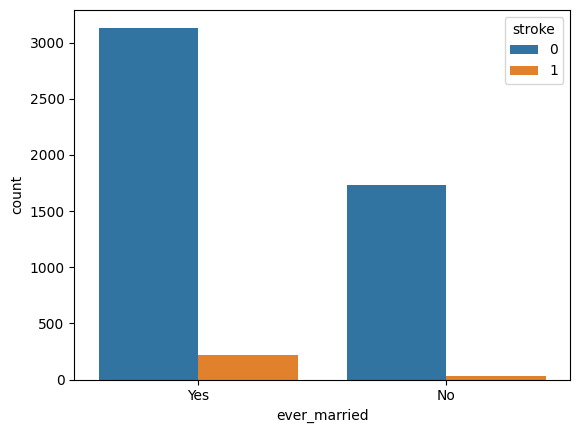

In [156]:
sns.countplot(data=df , x= 'ever_married' , hue="stroke")

In [86]:
# Suggested step: In gender column, As there's only one record with 'Other' value. We can drop it
df[df['gender']=='Other']


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,56156,Other,26.0,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


In [87]:
df = df[df['gender']!='Other']

In [88]:
df[df['gender']=='Other']

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


In [89]:
df['gender'].value_counts()

,count
gender,
Female,2994
Male,2115


In [90]:
df['work_type'].value_counts()

,count
work_type,
Private,2924
Self-employed,819
children,687
Govt_job,657
Never_worked,22


In [91]:
df['smoking_status'].value_counts()

,count
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,884
smokes,789


**Your Observations:** (Optional)
- What patterns do you notice in these categorical features?
- Which categories seem to have higher stroke rates?

In [92]:
"""
gender:
  not a big difference in genderit is just the gap between the count of females and males

work_type:
  people who never worked or childern have never had stroke
  people who work private are more likely to get a stroke more than self employed or wwork in governate jobs
  people with governate jobs are most likely to get stroke more than people who work governate jobes

note: the data is so imbalanced it is hard to tell for sure
"""

'\ngender:\n  not a big difference in genderit is just the gap between the count of females and males\n\nwork_type:\n  people who never worked or childern have never had stroke\n  people who work private are more likely to get a stroke more than self employed or wwork in governate jobs\n  people with governate jobs are most likely to get stroke more than people who work governate jobes \n\nnote: the data is so imbalanced it is hard to tell for sure \n'

### Task 2.3: Numerical Distributions

Create histograms or KDE plots for the following numerical features:
1. `age`
2. `avg_glucose_level`
3. `bmi`

**Important:**
Plot them side by side. Use subplots to organize your visualizations.

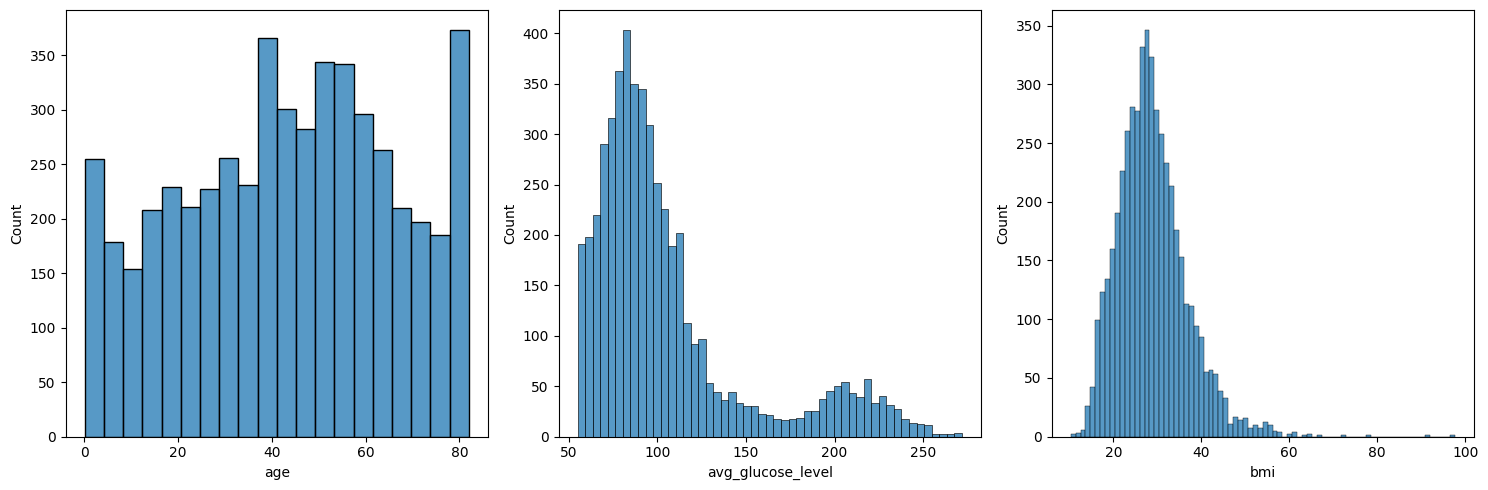

In [93]:
# Histogram for age, avg_glucose_level and bmi
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(data=df,x="age")

plt.subplot(1,3,2)
sns.histplot(data=df , x="avg_glucose_level")

plt.subplot(1,3,3)
sns.histplot(data=df,x="bmi")

plt.tight_layout()

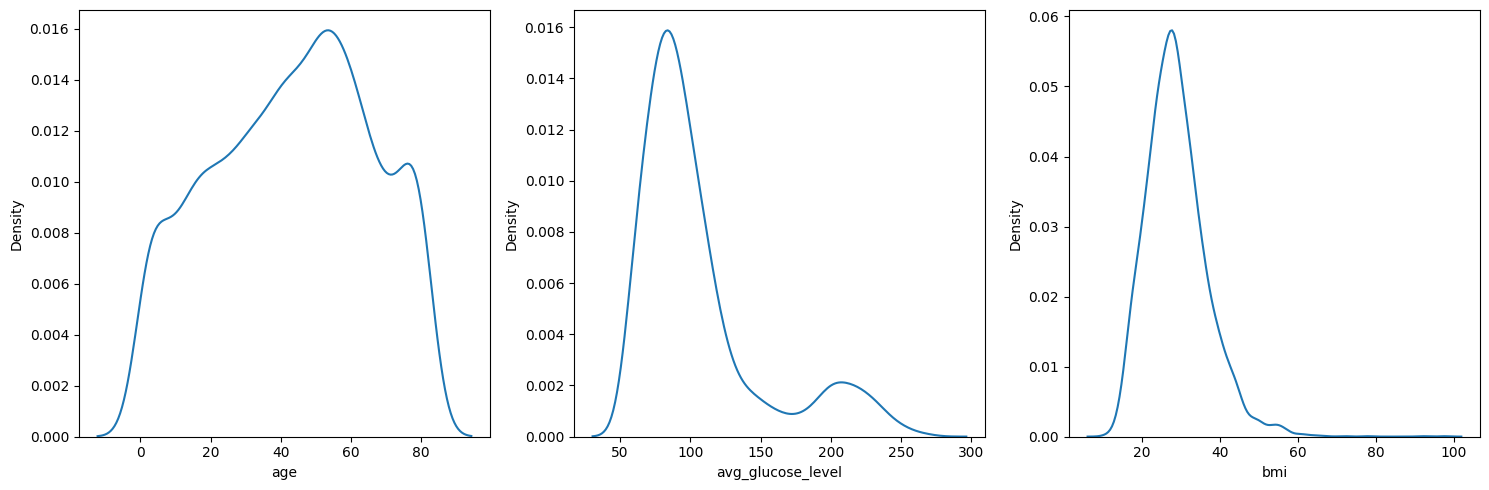

In [94]:
# Histogram for age, avg_glucose_level and bmi
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.kdeplot(data=df,x="age")

plt.subplot(1,3,2)
sns.kdeplot(data=df , x="avg_glucose_level")

plt.subplot(1,3,3)
sns.kdeplot(data=df,x="bmi")

plt.tight_layout()

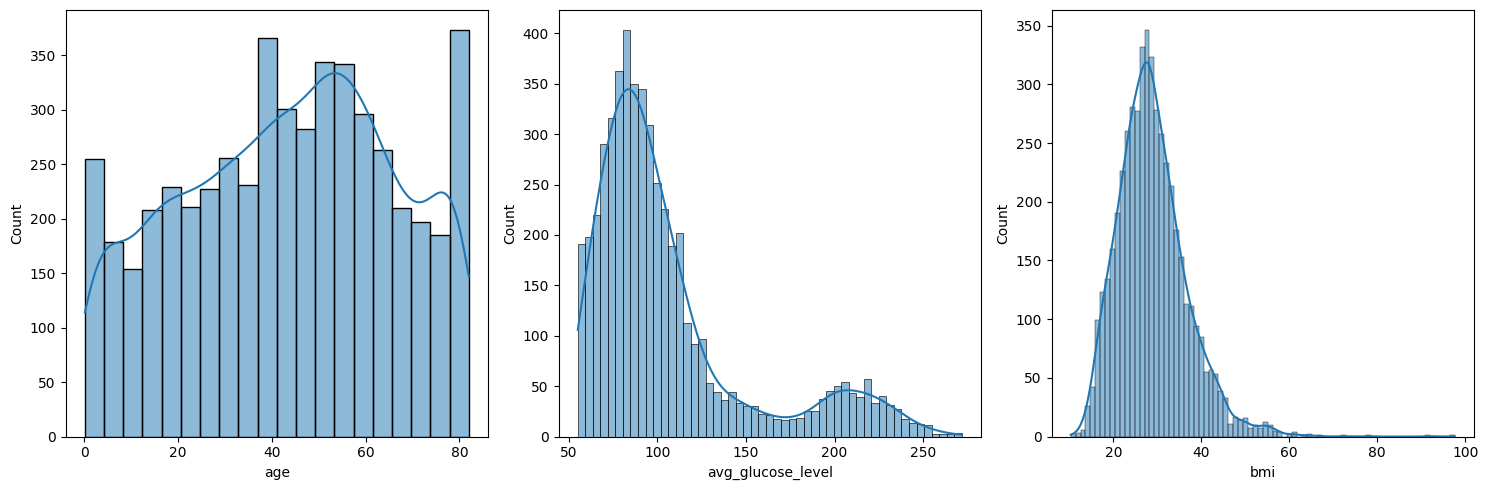

In [95]:
# Histogram for age, avg_glucose_level and bmi
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(data=df,x="age",kde=True)

plt.subplot(1,3,2)
sns.histplot(data=df , x="avg_glucose_level",kde=True)

plt.subplot(1,3,3)
sns.histplot(data=df,x="bmi",kde=True)

plt.tight_layout()

### Task 2.4: Correlation Analysis

Create a heatmap to show the correlation between numerical variables.

Select only numerical columns: `age`, `hypertension`, `heart_disease`, `avg_glucose_level`, `bmi`, and `stroke`.

<Axes: >

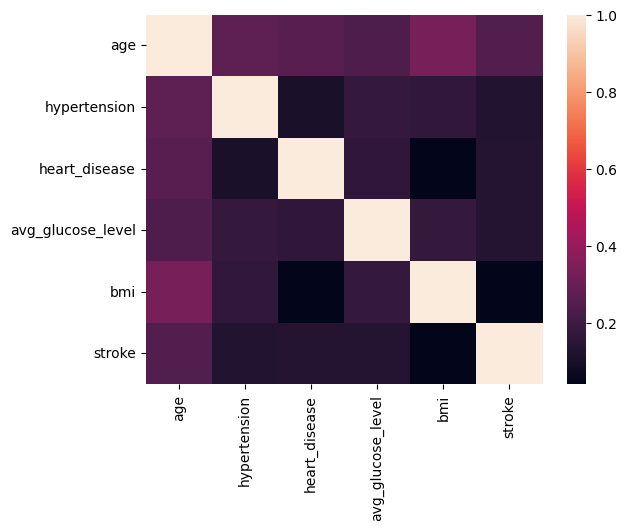

In [96]:
# Select features
numerical_features = df[["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi","stroke"]]
# Correlation heatmap
sns.heatmap(numerical_features.corr())

In [97]:
numerical_features.corr()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.000000,0.276367,0.263777,0.238323,0.333314,0.245239
hypertension,0.276367,1.000000,0.108292,0.174540,0.167770,0.127891
heart_disease,0.263777,0.108292,1.000000,0.161907,0.041322,0.134905
avg_glucose_level,0.238323,0.174540,0.161907,1.000000,0.175672,0.131991
bmi,0.333314,0.167770,0.041322,0.175672,1.000000,0.042341
stroke,0.245239,0.127891,0.134905,0.131991,0.042341,1.000000


**Your Observations:** (Optional)
- Which features show the strongest correlation with stroke?

In [98]:
"""
age then heart_disease then avg_glucose_level then hypertension

note: I undertood that from the values but I understood nothing from the heatmap
"""

'\nage then heart_disease then avg_glucose_level then hypertension\n\nnote: I undertood that from the values but I understood nothing from the heatmap\n'

---

## Part 3: Data Preprocessing (Cleaning)

### Task 3.1: Handling Missing Values

Check for missing values in the dataset and identify which columns have them.

In [99]:
# Check for missing values
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


**Task:** Fill the missing values in the `bmi` column using either the mean or median.

In [100]:
# Fill missing values in bmi with median because I think it is skewed to the left from the histogram
df['bmi'].fillna(df['bmi'].median(),inplace=True)

/tmp/ipykernel_2606/3460867254.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(),inplace=True)


In [101]:
# Verify no missing values remain
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


### Task 3.2: Handling Duplicates

Check for duplicate rows and remove them if any exist.

In [102]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [103]:
# Remove duplicates if any

### Task 3.3: Remove Irrelevant Columns

Drop the `id` column as it has no predictive power.

In [104]:
# Drop the id column
df.drop("id",axis=1,inplace=True)

In [105]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

### Task 3.4: Outlier Detection

Use a boxplot to visualize outliers in `avg_glucose_level`.

<Axes: ylabel='avg_glucose_level'>

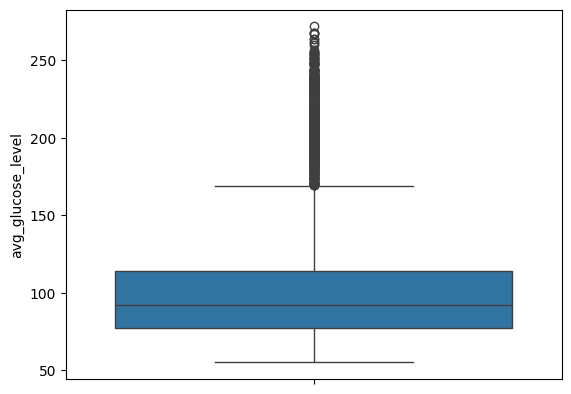

In [106]:
# Boxplot for avg_glucose_level
sns.boxplot(data=df,y='avg_glucose_level')

In [107]:
# Remove outliers if needed
q1 = df['bmi'].quantile(0.25)
q3= df['bmi'].quantile(0.75)
IQR = q3 - q3

lower_bounder = q1 - 1.5*IQR
upper_bounder = q3 + 1.5* IQR

df['bmi'][(df['bmi']<lower_bounder) |( df['bmi']>upper_bounder)].count()

np.int64(2534)

In [108]:
df.shape

(5109, 11)

In [109]:
2534/5109

0.4959874730867097

**Your Observations:** (Optional)
- Did you find outliers ?
- If found, should we remove them ? Why / Why not ?

In [110]:
"""
we should not drop the outliers because it is neaarlt 50% of the data
"""

'\nwe should not drop the outliers because it is neaarlt 50% of the data\n'

---

## Part 4: Data Splitting

### Task 4.1: Separate Features and Target

Separate your dataset into:
- `X`: All features (independent variables)
- `y`: Target variable (`stroke`)

In [144]:
# Separate features and target
X= df.drop("stroke", axis=1)
Y=df['stroke']

In [145]:
X.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status'],
      dtype='object')

In [146]:
Y

,stroke
0,1
1,1
2,1
3,1
4,1
...,...
5105,0
5106,0
5107,0
5108,0


### Task 4.2: Train-Test Split

Split the data into training (80%) and testing (20%) sets using `train_test_split` from sklearn.

Use `random_state=42` for reproducibility.

In [114]:
# Import train_test_split
from sklearn.model_selection import train_test_split

In [147]:
# Split the data
x_train , x_test , y_train , y_test = train_test_split(X,Y,test_size=0.2)

### Task 4.3: Verify Split Shapes

Print the shapes of `X_train`, `X_test`, `y_train`, and `y_test` to verify the split.

In [148]:
# Print shapes
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4087, 10)
(1022, 10)
(4087,)
(1022,)


---
## Part 5: Feature Transformation

### Task 5.1: Encoding

Apply Encoding to the following categorical variables:
- `gender`
- `work_type`
- `smoking_status`
- `ever_married`
- `Residence_type`

For each feature, check if it's an **Ordinal** or **Nominal**, **Binary-Categorical** or **Multi-Categorical** Feature.  
Use the suitable encoder based on your obseravations.

In [132]:
df['gender'].value_counts() #binary

,count
gender,
Female,2994
Male,2115


In [133]:
# Encoding
df['gender'] = df['gender'].map({"Female":0,"Male":1})

In [129]:
df['work_type'].value_counts() #norminal

,count
work_type,
Private,2924
Self-employed,819
children,687
Govt_job,657
Never_worked,22


In [141]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df['work_type'] = label.fit_transform(df['work_type'])

In [142]:
df['smoking_status'].value_counts() #norminal

,count
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,884
smokes,789


In [143]:
df['smoking_status'] = label.fit_transform(df['smoking_status'])

In [130]:
df['ever_married'].value_counts() #binary

,count
ever_married,
Yes,3353
No,1756


In [134]:
df['ever_married'] = df['ever_married'].map({"Yes":1,"No" : 0})

In [131]:
df['Residence_type'].value_counts() #binary

,count
Residence_type,
Urban,2596
Rural,2513


In [135]:
df['Residence_type'] = df['Residence_type'].map({"Urban":0,"Rural":1})

In [ ]:
#when I was done with the encoding I ran the train test split again

---

## Part 6: Feature Scaling

### Task 6.1: Scale Numerical Features

The features `age`, `avg_glucose_level`, and `bmi` have different scales.

Apply `StandardScaler` or `MinMaxScaler` to these three columns.

In [149]:
# Import scaler
from sklearn.preprocessing import MinMaxScaler , StandardScaler
std_scaler = StandardScaler()
minmx_scaler = MinMaxScaler()

In [150]:
# Apply scaling to age, avg_glucose_level, and bmi
x_train[["age", "avg_glucose_level",  "bmi"]] = std_scaler.fit_transform(x_train[["age", "avg_glucose_level",  "bmi"]])
x_test[["age", "avg_glucose_level",  "bmi"]] = std_scaler.fit_transform(x_test[["age", "avg_glucose_level",  "bmi"]])

In [ ]:
# Apply scaling to age, avg_glucose_level, and bmi
scaler = StandardScaler()
numeric_features = ["age", "avg_glucose_level", "bmi"]
x_train[numeric_features] = scaler.fit_transform(x_train[numeric_features])
x_test[numeric_features] = scaler.transform(x_test[numeric_features])

---

## Part 7: Handling Class Imbalance

### Task 7.1: Check Current Class Distribution

Display the value counts of the target variable before handling imbalance.

In [151]:
# Check current distribution
y_train.value_counts()

,count
stroke,
0,3891
1,196


### Task 7.2: Handle Unbalanced Data

Apply oversampling, undersampling, or SMOTE to balance the dataset.

Import the appropriate method before applying it.

In [152]:
# Handle unbalanced data (choose your method)
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy="minority")
x_train, y_train = smote.fit_resample(x_train,y_train)

### Task 7.3: Verify Class Balance

Check the value counts of the target variable after oversampling to ensure classes are balanced.

In [153]:
# Verify new distribution
y_train.value_counts()

,count
stroke,
0,3891
1,3891


---

## Conclusion

### Task: High-Risk Stroke Patient Persona (Optional)

Based on your exploratory data analysis, write a short paragraph describing the **"persona" of a high-risk stroke patient**. Consider factors like age, glucose levels, work type, and medical history.

In [157]:
"""
# Persona
a person who is not a child, does not matter if he smokes or used to smoke ar never smoked if he works he might get a stroke specially if he is old
if you are married you have higher chance to get a stroke than the unmarried

# Summary
stay healthy and single, exercise, and if you need to work choose a governate job and do not work for private companies

"""

'\n# Persona\na person who is not a child, does not matter if he smokes or used to smoke ar never smoked if he works he might get a stroke specially if he is old\nif you are married you have higher chance to get a stroke than the unmarried\n\n# Summary\nstay healthy and single, exercise, and if you need to work choose a governate job and do not work for private companies\n\n'

**Good luck! 🎯**